In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import mne
from mne.datasets.sleep_physionet.age import fetch_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
import warnings

# Suppress verbose processing logs
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

In [3]:
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing pipeline on device: {DEVICE}")

SAVE_DIR = "./data"
OUTPUT_FILE = os.path.join(SAVE_DIR, "sleep_combined.pt")
CHECKPOINT_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

STAGE_MAPPING = {
    "Sleep stage W": 0, "Sleep stage 1": 1, "Sleep stage 2": 2,
    "Sleep stage 3": 3, "Sleep stage 4": 3, "Sleep stage R": 4
}
EPOCH_SEC = 30       
TARGET_SFREQ = 100   # 100Hz -> 3000 samples per epoch
TIME_STEPS = 3000    
LATENT_DIM = 128     
NUM_CLASSES = 5      
PRETRAIN_EPOCHS = 40
EVAL_EPOCHS = 30
BATCH_SIZE = 64

Executing pipeline on device: cuda:1


In [4]:
class MyConv1dPadSame(nn.Module):
    """
    extend nn.Conv1d to support SAME padding
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, groups=1):
        super(MyConv1dPadSame, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.groups = groups
        self.conv = torch.nn.Conv1d(
            in_channels=self.in_channels, 
            out_channels=self.out_channels, 
            kernel_size=self.kernel_size, 
            stride=self.stride, 
            groups=self.groups)

    def forward(self, x):
        
        net = x
        
        # compute pad shape
        in_dim = net.shape[-1]
        out_dim = (in_dim + self.stride - 1) // self.stride
        p = max(0, (out_dim - 1) * self.stride + self.kernel_size - in_dim)
        pad_left = p // 2
        pad_right = p - pad_left
        net = F.pad(net, (pad_left, pad_right), "constant", 0)
        
        net = self.conv(net)

        return net

In [5]:
class MyMaxPool1dPadSame(nn.Module):
    """
    extend nn.MaxPool1d to support SAME padding
    """
    def __init__(self, kernel_size):
        super(MyMaxPool1dPadSame, self).__init__()
        self.kernel_size = kernel_size
        self.stride = 1
        self.max_pool = torch.nn.MaxPool1d(kernel_size=self.kernel_size)

    def forward(self, x):
        
        net = x
        
        # compute pad shape
        in_dim = net.shape[-1]
        out_dim = (in_dim + self.stride - 1) // self.stride
        p = max(0, (out_dim - 1) * self.stride + self.kernel_size - in_dim)
        pad_left = p // 2
        pad_right = p - pad_left
        net = F.pad(net, (pad_left, pad_right), "constant", 0)
        
        net = self.max_pool(net)
        
        return net

In [6]:
class BasicBlock(nn.Module):
    """
    ResNet Basic Block
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, groups, downsample, use_bn, use_do, is_first_block=False):
        super(BasicBlock, self).__init__()

        self.in_channels = in_channels
        self.kernel_size = kernel_size
        self.out_channels = out_channels
        self.stride = stride
        self.groups = groups
        self.downsample = downsample
        if self.downsample:
            self.stride = stride
        else:
            self.stride = 1
        self.is_first_block = is_first_block
        self.use_bn = use_bn
        self.use_do = use_do

        # the first conv
        self.bn1 = nn.BatchNorm1d(in_channels)
        self.relu1 = nn.ReLU()
        self.do1 = nn.Dropout(p=0.5)
        self.conv1 = MyConv1dPadSame(
            in_channels=in_channels, 
            out_channels=out_channels, 
            kernel_size=kernel_size, 
            stride=self.stride,
            groups=self.groups)

        # the second conv
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.do2 = nn.Dropout(p=0.5)
        self.conv2 = MyConv1dPadSame(
            in_channels=out_channels, 
            out_channels=out_channels, 
            kernel_size=kernel_size, 
            stride=1,
            groups=self.groups)
                
        self.max_pool = MyMaxPool1dPadSame(kernel_size=self.stride)

    def forward(self, x):
        
        identity = x
        
        # the first conv
        out = x
        if not self.is_first_block:
            if self.use_bn:
                out = self.bn1(out)
            out = self.relu1(out)
            if self.use_do:
                out = self.do1(out)
        out = self.conv1(out)
        
        # the second conv
        if self.use_bn:
            out = self.bn2(out)
        out = self.relu2(out)
        if self.use_do:
            out = self.do2(out)
        out = self.conv2(out)
        
        # if downsample, also downsample identity
        if self.downsample:
            identity = self.max_pool(identity)
            
        # if expand channel, also pad zeros to identity
        if self.out_channels != self.in_channels:
            identity = identity.transpose(-1,-2)
            ch1 = (self.out_channels-self.in_channels)//2
            ch2 = self.out_channels-self.in_channels-ch1
            identity = F.pad(identity, (ch1, ch2), "constant", 0)
            identity = identity.transpose(-1,-2)
        
        # shortcut
        out += identity

        return out
    

In [7]:
class FourierEncoder(nn.Module):
    def __init__(self, in_channels, in_length, out_channels, kernel_size=3, initial_stride=1):
        super(FourierEncoder, self).__init__()
        
        # --- Amplitude branch ---
        # Process absolute values (amplitude)
        self.abs_conv = nn.Conv1d(in_channels, 16, kernel_size=kernel_size, stride=initial_stride, padding=kernel_size//2)
        self.abs_pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.abs_block1 = BasicBlock(
            in_channels=16, out_channels=32, kernel_size=kernel_size, stride=2, groups=1, 
            downsample=True, use_bn=False, use_do=False, is_first_block=True
        )
        self.abs_block2 = BasicBlock(
            in_channels=32, out_channels=64, kernel_size=kernel_size, stride=2, groups=1, 
            downsample=True, use_bn=False, use_do=False, is_first_block=False
        )

        # --- Phase branch ---
        # Process phase values (angle)
        self.ang_conv = nn.Conv1d(in_channels, 16, kernel_size=kernel_size, stride=initial_stride, padding=kernel_size//2)
        # self.ang_pool = nn.MaxPool1d(kernel_size=2, stride=2)
        # self.ang_conv2 = nn.Conv1d(16, 32, kernel_size=kernel_size, stride=initial_stride, padding=kernel_size//2)
        # self.ang_conv3 = nn.Conv1d(32, 64, kernel_size=kernel_size, stride=initial_stride, padding=kernel_size//2)

        self.ang_block1 = BasicBlock(
            in_channels=16, out_channels=32, kernel_size=kernel_size, stride=2, groups=1, 
            downsample=True, use_bn=False, use_do=False, is_first_block=True
        )
        self.ang_block2 = BasicBlock(
            in_channels=32, out_channels=64, kernel_size=kernel_size, stride=2, groups=1, 
            downsample=True, use_bn=False, use_do=False, is_first_block=False
        )

        if in_length == 200:
            self.fc_abs = nn.Linear(26, 1)
            self.fc_angle = nn.Linear(26, 1)
        elif in_length == 128:
            self.fc_abs = nn.Linear(17, 1)
            self.fc_angle = nn.Linear(17, 1)
        elif in_length == 100:
            self.fc_abs = nn.Linear(13, 1)
            self.fc_angle = nn.Linear(13, 1)
        elif in_length == 480:
            self.fc_abs = nn.Linear(61, 1)
            self.fc_angle = nn.Linear(61, 1)
        elif in_length == 1000:
            self.fc_abs = nn.Linear(126, 1)
            self.fc_angle = nn.Linear(126, 1)
        elif in_length == 3004:
            self.fc_abs = nn.Linear(376, 1)
            self.fc_angle = nn.Linear(376, 1)
        elif in_length == 3000:
            self.fc_abs = nn.Linear(376, 1)
            self.fc_angle = nn.Linear(376, 1)
        # Fully connected layer combining both branches.
        # Each branch outputs 64 channels after global pooling.
        self.fc = nn.Linear(64, 128) # Isoalign
        # self.fc = nn.Linear(64, 192) # CLIP
        
    def forward(self, x):
        # Compute amplitude and phase from complex input.
        x_abs = torch.abs(x).float()    # shape: (B, C, T)
        x_ang = torch.angle(x).float()  # shape: (B, C, T)
        # Process amplitude branch.
        a = self.abs_conv(x_abs)
        a = F.relu(a)
        a = self.abs_block1(a)
        a = self.abs_block2(a)
        # Global average pooling over time dimension.
        a = self.fc_abs(a).squeeze(-1) # shape: (B, 64)
        
        # # Process phase branch.
        p = self.ang_conv(x_ang)
        p = F.relu(p)
        p = self.ang_block1(p)
        p = self.ang_block2(p)
        p = self.fc_angle(p).squeeze(-1) # shape: (B, 64)
        
        # Concatenate features from both branches.
        out = torch.cat([a, p], dim=1)  # shape: (B, 128)
        # out = self.fc(a)
        return out

In [8]:
class ResNet1D(nn.Module):
    """
    Input:
        X: (n_samples, n_channel, n_length)
        Y: (n_samples)
        
    Output:
        out: (n_samples)
        
    Pararmetes:
        in_channels: dim of input, the same as n_channel
        base_filters: number of filters in the first several Conv layer, it will double at every 4 layers
        kernel_size: width of kernel
        stride: stride of kernel moving
        groups: set larget to 1 as ResNeXt
        n_block: number of blocks
        n_classes: number of classes
    """
    def __init__(self, in_channels, base_filters, kernel_size, stride, groups, n_block, n_classes, downsample_gap=2, increasefilter_gap=4, use_bn=True, use_do=True, verbose=False, backbone=False, output_dim=200):
        super(ResNet1D, self).__init__()
        
        self.out_dim = output_dim
        self.backbone = backbone
        self.verbose = verbose
        self.n_block = n_block
        self.kernel_size = kernel_size
        self.stride = stride
        self.groups = groups
        self.use_bn = use_bn
        self.use_do = use_do

        self.downsample_gap = downsample_gap # 2 for base model
        self.increasefilter_gap = increasefilter_gap # 4 for base model

        # first block
        self.first_block_conv = MyConv1dPadSame(in_channels=in_channels, out_channels=base_filters, kernel_size=self.kernel_size, stride=1)
        self.first_block_bn = nn.BatchNorm1d(base_filters)
        self.first_block_relu = nn.ReLU()
        out_channels = base_filters
                
        # residual blocks
        self.basicblock_list = nn.ModuleList()
        for i_block in range(self.n_block):
            # is_first_block
            if i_block == 0:
                is_first_block = True
            else:
                is_first_block = False
            # downsample at every self.downsample_gap blocks
            if i_block % self.downsample_gap == 1:
                downsample = True
            else:
                downsample = False
            # in_channels and out_channels
            if is_first_block:
                in_channels = base_filters
                out_channels = in_channels
            else:
                # increase filters at every self.increasefilter_gap blocks
                in_channels = int(base_filters*2**((i_block-1)//self.increasefilter_gap))
                if (i_block % self.increasefilter_gap == 0) and (i_block != 0):
                    out_channels = in_channels * 2
                else:
                    out_channels = in_channels
            
            tmp_block = BasicBlock(
                in_channels=in_channels, 
                out_channels=out_channels, 
                kernel_size=self.kernel_size, 
                stride = self.stride, 
                groups = self.groups, 
                downsample=downsample, 
                use_bn = self.use_bn, 
                use_do = self.use_do, 
                is_first_block=is_first_block)
            self.basicblock_list.append(tmp_block)

        # final prediction
        self.final_bn = nn.BatchNorm1d(out_channels)
        self.final_relu = nn.ReLU(inplace=True)
        # self.do = nn.Dropout(p=0.5)
        self.dense = nn.Linear(out_channels, n_classes)
        self.dense2 = nn.Linear(out_channels, self.out_dim)
        # self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = x.transpose(-1,-2) # RESNET 1D takes channels first
        out = x
        
        # first conv
        if self.verbose:
            print('input shape', out.shape)
        out = self.first_block_conv(out)
        if self.verbose:
            print('after first conv', out.shape)
        if self.use_bn:
            out = self.first_block_bn(out)
        out = self.first_block_relu(out)
        
        # residual blocks, every block has two conv
        for i_block in range(self.n_block):
            net = self.basicblock_list[i_block]
            if self.verbose:
                print('i_block: {0}, in_channels: {1}, out_channels: {2}, downsample: {3}'.format(i_block, net.in_channels, net.out_channels, net.downsample))
            out = net(out)
            if self.verbose:
                print(out.shape)

        # final prediction
        if self.use_bn:
            out = self.final_bn(out)
        out = self.final_relu(out)
        out = out.mean(-1)
        if self.backbone:
            out = self.dense2(out)
            return None, out
        # out = self.do(out)
        out_class = self.dense(out)
        # out = self.softmax(out)
        
        return out_class, out    

In [9]:
def conbr_block_2d(in_channels, out_channels, kernel_size, stride, padding):
    """A 2D convolutional block: Conv2d -> BatchNorm2d -> ReLU."""
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

In [10]:
class UNET_2D_simp(nn.Module):
    def __init__(self, input_channels, output_channels, layer_n, spect_freq, spect_time, kernel_size):
        """
        A simplified U-Net for 2D data (e.g. wavelet spectrograms).

        Parameters:
        - input_channels: Number of input channels (e.g., 1 for a single spectrogram channel)
        - output_channels: Number of output channels (e.g., number of classes or reconstruction channels)
        - layer_n: Base number of filters
        - kernel_size: Size of the convolution kernel (assumed square)
        - depth: (Not used in this simplified version, but could control number of layers)
        - args: Additional arguments (if needed)
        """
        super(UNET_2D_simp, self).__init__()
        self.input_channels = input_channels
        self.layer_n = layer_n
        self.kernel_size = kernel_size
        self.output_channels = output_channels
        self.spec_freq = spect_freq
        self.spec_time = spect_time

        # Pooling layers (2D average pooling)
        self.AvgPool2D1 = nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2))
        self.AvgPool2D2 = nn.AvgPool2d(kernel_size=(4, 4), stride=(4, 4))
        
        # Encoder
        self.layer1 = self.down_layer_2d(self.input_channels, self.layer_n, self.kernel_size, stride=1, padding=self.kernel_size//2)
        self.layer2 = self.down_layer_2d(self.layer_n, self.layer_n * 2, self.kernel_size, stride=2, padding=self.kernel_size//2)
        # Concatenate with pooled input (similar to adding residual skip from input)
        self.layer3 = self.down_layer_2d(self.layer_n * 2 + self.input_channels, self.layer_n * 3, self.kernel_size, stride=2, padding=self.kernel_size//2)
        self.layer4 = self.down_layer_2d(self.layer_n * 3 + self.input_channels, self.layer_n * 4, self.kernel_size, stride=2, padding=self.kernel_size//2)
        
        # Decoder
        # self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # self.cbr_up1 = conbr_block_2d(self.layer_n * 4 + self.layer_n * 3, self.layer_n * 3, self.kernel_size, stride=1, padding=self.kernel_size//2)
        # self.cbr_up2 = conbr_block_2d(self.layer_n * 3 + self.layer_n * 2, self.layer_n * 2, self.kernel_size, stride=1, padding=self.kernel_size//2)
        # self.cbr_up3 = conbr_block_2d(self.layer_n * 2 + self.layer_n, self.layer_n, self.kernel_size, stride=1, padding=self.kernel_size//2)
        
        # Final output convolution layer to map to desired output channels
        # self.outcov = nn.Conv2d(self.layer_n, output_channels, kernel_size=self.kernel_size, stride=1, padding=self.kernel_size//2)

        if self.spec_freq == 48 and self.spec_time == 200:
            self.fc = nn.Linear(25, 1)
            self.fc2 = nn.Linear(6, 1)

        if self.spec_freq == 48 and self.spec_time == 128:
            self.fc = nn.Linear(16, 1)
            self.fc2 = nn.Linear(6, 1)

        if self.spec_freq == 48 and self.spec_time == 100:
            self.fc = nn.Linear(13, 1)
            self.fc2 = nn.Linear(6, 1)

        if self.spec_freq == 48 and self.spec_time == 480:
            self.fc = nn.Linear(60, 1)
            self.fc2 = nn.Linear(6, 1)

        if self.spec_freq == 48 and self.spec_time == 1000:
            self.fc = nn.Linear(125, 1)
            self.fc2 = nn.Linear(6, 1)

        if self.spec_freq == 48 and self.spec_time == 200:
            self.fc = nn.Linear(25, 1)
            self.fc2 = nn.Linear(6, 1)

        if self.spec_freq == 48 and self.spec_time == 3004:
            self.fc = nn.Linear(376, 1)
            self.fc2 = nn.Linear(6, 1)

        if self.spec_freq == 48 and self.spec_time == 3000:
            self.fc = nn.Linear(375, 1)
            self.fc2 = nn.Linear(6, 1)
    def down_layer_2d(self, in_channels, out_channels, kernel_size, stride, padding):
        """Creates a downsampling layer using a conv block."""
        return nn.Sequential(
            conbr_block_2d(in_channels, out_channels, kernel_size, stride, padding)
        )

    def forward(self, x):
        # x is expected to have shape: (batch, channels, freq, time)
        # Create multi-scale pooled inputs from the original signal for skip connections.
        pool_x1 = self.AvgPool2D1(x)  # Downsample by factor of 2
        pool_x2 = self.AvgPool2D2(x)  # Downsample by factor of 4
        # Encoder path
        out_0 = self.layer1(x)          # (B, layer_n, F, T)
        out_1 = self.layer2(out_0)        # (B, layer_n*2, F/2, T/2)
        
        # Concatenate skip connection from original input (pooled) with out_1
        x1 = torch.cat([out_1, pool_x1], dim=1)  # (B, layer_n*2 + input_channels, F/2, T/2)
        out_2 = self.layer3(x1)          # (B, layer_n*3, F/4, T/4)
        
        x2 = torch.cat([out_2, pool_x2], dim=1)  # (B, layer_n*3 + input_channels, F/4, T/4)
        x3 = self.layer4(x2)             # (B, layer_n*4, F/8, T/8)

        # Decoder path
        # up = self.upsample(x3)           # Upsample to (B, layer_n*4, F/4, T/4)
        # up = torch.cat([up, out_2], dim=1)  # (B, layer_n*4 + layer_n*3, F/4, T/4)
        # up = self.cbr_up1(up)            # (B, layer_n*3, F/4, T/4)
        
        # up = self.upsample(up)           # Upsample to (B, layer_n*3, F/2, T/2)
        # up = torch.cat([up, out_1], dim=1)   # (B, layer_n*3 + layer_n*2, F/2, T/2)
        # up = self.cbr_up2(up)            # (B, layer_n*2, F/2, T/2)
        
        # up = self.upsample(up)           # Upsample to (B, layer_n*2, F, T)
        # up = torch.cat([up, out_0], dim=1)   # (B, layer_n*2 + layer_n, F, T)
        # up = self.cbr_up3(up)            # (B, layer_n, F, T)
        
        # out = self.outcov(up)            # (B, output_channels, F, T)

        return None, self.fc2(self.fc(x3).squeeze()).squeeze()

In [11]:
from models.frameworks import IsoAlign

In [12]:
# ### 1. Custom Raw Preprocessing Pipeline

# %%
import glob

print("Locating local raw recordings from Sleep-EDF...")

# 🚨 CHANGE THIS to the actual folder path where your local .edf files are stored
LOCAL_DATA_DIR = "/home/gella.saikrishna/sleep-edf-database-expanded-1.0.0/sleep-edf-database-expanded-1.0.0/sleep-cassette"

# Automatically find all PSG and Hypnogram files in your directory
psg_files = sorted(glob.glob(os.path.join(LOCAL_DATA_DIR, "*PSG.edf")))
hypno_files = sorted(glob.glob(os.path.join(LOCAL_DATA_DIR, "*Hypnogram.edf")))

# Zip them together so they pair up correctly
raw_data_files = list(zip(psg_files, hypno_files))

if len(raw_data_files) == 0:
    raise FileNotFoundError(f"No EDF files found in {LOCAL_DATA_DIR}. Check your path!")

print(f"✅ Found {len(raw_data_files)} paired recording sessions locally.")

all_epochs_list = []
all_labels_list = []

print("\nPreprocessing raw EEG signals...")
for psg_file, hypno_file in raw_data_files:
    raw = mne.io.read_raw_edf(psg_file, preload=True)
    eeg_channels = [ch for ch in raw.ch_names if 'EEG' in ch]
    if len(eeg_channels) > 0:
        raw.pick_channels([eeg_channels[0]])
    else:
        continue
        
    raw.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin')
    if raw.info['sfreq'] != TARGET_SFREQ:
        raw.resample(TARGET_SFREQ, npad="auto")
        
    annotations = mne.read_annotations(hypno_file)
    raw.set_annotations(annotations, emit_warning=False)
    
    events, event_id = mne.events_from_annotations(raw, event_id=STAGE_MAPPING, chunk_duration=float(EPOCH_SEC))
    tmax = 30.0 - 1.0 / TARGET_SFREQ 
    epochs = mne.Epochs(raw=raw, events=events, event_id=event_id, tmin=0.0, tmax=tmax, baseline=None, preload=True, reject=None)
    
    data = epochs.get_data() 
    labels = epochs.events[:, -1]
    data = np.squeeze(data, axis=1)
    
    all_epochs_list.append(data)
    all_labels_list.append(labels)

X = np.concatenate(all_epochs_list, axis=0)
y = np.concatenate(all_labels_list, axis=0)

print("Applying global Z-score standardization...")
X = (X - np.mean(X)) / (np.std(X) + 1e-6)

print("Splitting dataset into stratified subsets...")
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42, stratify=y_train_val)

# Packing the variables using identical keys ('samples', 'labels') expected by downstream components
processed_dataset_object = {
    "train": {"samples": torch.from_numpy(X_train).float(), "labels": torch.from_numpy(y_train).long()},
    "val": {"samples": torch.from_numpy(X_val).float(), "labels": torch.from_numpy(y_val).long()},
    "test": {"samples": torch.from_numpy(X_test).float(), "labels": torch.from_numpy(y_test).long()}
}
torch.save(processed_dataset_object, OUTPUT_FILE)
print(f"✅ Successfully created and saved custom splits to {OUTPUT_FILE}")


Locating local raw recordings from Sleep-EDF...
✅ Found 153 paired recording sessions locally.

Preprocessing raw EEG signals...


KeyboardInterrupt: 

In [13]:

# %% [markdown]
# ### 2. Self-Supervised Multi-View Datasets

# %%
class SleepEDF_Pretrain_Dataset(Dataset):
    def __init__(self, pt_file_path=OUTPUT_FILE, split="train"):
        data_obj = torch.load(pt_file_path, map_location="cpu")[split]
        self.data = data_obj["samples"]
        self.window = torch.hann_window(128)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x_t = self.data[idx] 
        x_time = x_t.unsqueeze(0) 
        
        x_fft = torch.fft.rfft(x_t)
        x_fourier = torch.stack([torch.abs(x_fft), torch.angle(x_fft)], dim=0)
        
        x_stft = torch.stft(x_t, n_fft=128, hop_length=64, window=self.window, return_complex=True)
        
        # Exact dimension alignment matching your .ipynb file
        x_wavelet = torch.abs(x_stft)[:64, :] 
        x_wavelet = F.pad(x_wavelet, (0, 1)) 
        x_wavelet = x_wavelet.unsqueeze(0) 
        
        return x_time, x_fourier, x_wavelet

class SleepEDF_Evaluation_Dataset(Dataset):
    def __init__(self, pt_file_path=OUTPUT_FILE, split="train"):
        data_obj = torch.load(pt_file_path, map_location="cpu")[split]
        self.samples = data_obj["samples"].unsqueeze(2)  # Reshaped to [N, 3000, 1] for internal .transpose()
        self.labels = data_obj["labels"].long()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]


In [14]:
# %% [markdown]
# ### 3. Self-Supervised Pre-Training (IsoAlign)

# %%
pretrain_loader = DataLoader(SleepEDF_Pretrain_Dataset(split="train"), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Determine shapes dynamically matching the dataset outputs
_, _, sample_w = SleepEDF_Pretrain_Dataset(split="train")[0]
SPECT_FREQ = sample_w.shape[1]   
SPECT_TIME = sample_w.shape[2]   

# A. Time Encoder Architecture Configuration
time_encoder = ResNet1D(
    in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
    n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
    use_do=True, backbone=True, output_dim=LATENT_DIM
).to(DEVICE)

# B. Wavelet Spectrogram Encoder Architecture Configuration
spect_encoder = UNET_2D_simp(
    input_channels=1, output_channels=LATENT_DIM, layer_n=32, 
    spect_freq=SPECT_FREQ, spect_time=SPECT_TIME, kernel_size=3
)
# Monkey-patching identical layer dimensions from your notebook
spect_encoder.fc = nn.Linear(6, 1)
spect_encoder.fc2 = nn.Linear(8, 1)
spect_encoder = spect_encoder.to(DEVICE)

# C. Fourier Encoder Wrapper Architecture Configuration
class FourierWrapper(nn.Module):
    def __init__(self, in_length):
        super().__init__()
        self.enc = FourierEncoder(in_channels=2, in_length=in_length, out_channels=LATENT_DIM)
        if in_length == 3000:
            self.enc.fc_abs = nn.Linear(376, 1)
            self.enc.fc_angle = nn.Linear(376, 1)
            
    def forward(self, x): 
        return None, self.enc(x)

ft_encoder = FourierWrapper(in_length=TIME_STEPS).to(DEVICE)

# Framework Setup
class Args: wo_OB = False; wo_OF = False
model = IsoAlign(backbone=time_encoder, spect_encoder=spect_encoder, FT_encoder=ft_encoder, DEVICE=DEVICE, dim=LATENT_DIM, batch_size=BATCH_SIZE, args=Args()).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("\n🚀 Starting Self-Supervised Multi-View Pre-training...")
best_loss = float('inf')

for epoch in range(PRETRAIN_EPOCHS):
    model.train()
    total_loss = 0
    for batch_t, batch_f, batch_w in pretrain_loader:
        batch_t, batch_f = batch_t.to(DEVICE), batch_f.to(DEVICE)
        batch_w = batch_w.permute(0, 2, 3, 1).to(DEVICE) 
        
        optimizer.zero_grad()
        loss = model(batch_t, batch_w, batch_f)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(pretrain_loader)
    print(f"Pretrain Epoch [{epoch+1:02d}/{PRETRAIN_EPOCHS}] | Loss: {avg_loss:.4f}")
    
    # 🌟 1. Save the absolute best time encoder weights based on loss performance
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_encoder_path = os.path.join(CHECKPOINT_DIR, "lwa_best_time_encoder.pth")
        torch.save(model.encoder.state_dict(), best_encoder_path)
        print(f"   🌟 New best loss achieved! Saved encoder to: {best_encoder_path}")
        
    # 💾 2. UPDATED: Save a comprehensive recovery checkpoint at the end of EVERY epoch
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"lwa_checkpoint_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),          # Entire multi-view system state
        'optimizer_state_dict': optimizer.state_dict(),  # Adam optimizer states, running averages, learning rate tracking
        'loss': avg_loss
    }, checkpoint_path)
    print(f"   💾 Checkpoint saved for epoch {epoch+1} to: {checkpoint_path}")

KeyboardInterrupt: 

In [15]:

# %% [markdown]
# ### 4. Downstream Evaluation (Frozen Pre-trained Backbone + 1-Layer Linear Head)

# %%
train_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="train"), batch_size=128, shuffle=True)
val_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="val"), batch_size=128, shuffle=False)
test_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="test"), batch_size=128, shuffle=False)

# Reinitialize backbone and load pre-trained weights
eval_encoder = ResNet1D(
    in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
    n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
    use_do=False, backbone=True, output_dim=LATENT_DIM
).to(DEVICE)

eval_encoder.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "lwa_best_time_encoder.pth"), map_location=DEVICE))
print("\n🔒 Loaded Pre-trained Encoder weights and freezing parameters...")

for param in eval_encoder.parameters():
    param.requires_grad = False

# Exact 1-Layer Linear head setup configuration from your notebook block (nn.Linear(128, 5))
classifier_head = nn.Linear(LATENT_DIM, NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
eval_optimizer = optim.Adam(classifier_head.parameters(), lr=1e-2, weight_decay=1e-4)

# %%
def evaluate_pipeline(encoder_m, head_m, loader, print_breakdown=False):
    encoder_m.eval(); head_m.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for signals, labels in loader:
            _, features = encoder_m(signals.to(DEVICE))
            preds = torch.argmax(head_m(features), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    weighted_f1 = f1_score(all_targets, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_targets, all_preds)
    
    if print_breakdown:
        CLASS_NAMES = ["Wake (W)", "N1 Stage", "N2 Stage", "N3 Stage", "REM"]
        print("\n📊 DETAILED PERFORMANCE BREAKDOWN (PRE-TRAINED BACKBONE + 1-LAYER LINEAR HEAD):")
        print(f"   ➡️ Test Accuracy:    {acc*100:.2f}%")
        print(f"   ➡️ Cohen's Kappa:     {kappa:.4f}")
        print(f"   ➡️ Macro F1-Score:    {macro_f1:.4f}")
        print(f"   ➡️ Weighted F1-Score: {weighted_f1:.4f}")
        print("   ➡️ Stage-Specific F1-Scores:")
        for name, score in zip(CLASS_NAMES, f1_score(all_targets, all_preds, average=None)):
            print(f"       • {name.ljust(12)}: {score:.4f}")
    return acc, macro_f1

# %%
print("\n🏋️ Training Supervised 1-Layer Linear Head...")
best_val_f1 = 0.0

for epoch in range(EVAL_EPOCHS):
    eval_encoder.eval(); classifier_head.train()
    total_loss = 0
    for signals, labels in train_loader:
        eval_optimizer.zero_grad()
        with torch.no_grad():
            _, features = eval_encoder(signals.to(DEVICE))
        loss = criterion(classifier_head(features), labels.to(DEVICE))
        loss.backward()
        eval_optimizer.step()
        total_loss += loss.item()
        
    val_acc, val_f1 = evaluate_pipeline(eval_encoder, classifier_head, val_loader)
    print(f"Eval Epoch [{epoch+1:02d}/{EVAL_EPOCHS}] | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(classifier_head.state_dict(), os.path.join(CHECKPOINT_DIR, "linear_classifier_head.pth"))


KeyboardInterrupt: 

In [16]:

# %% [markdown]
# ### 5. Final Report Verification

# %%
print("\n🔒 Final Deployment Testing on Unseen Participants...")
classifier_head.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "linear_classifier_head.pth"), map_location=DEVICE))
_, _ = evaluate_pipeline(eval_encoder, classifier_head, test_loader, print_breakdown=True)


🔒 Final Deployment Testing on Unseen Participants...

📊 DETAILED PERFORMANCE BREAKDOWN (PRE-TRAINED BACKBONE + 1-LAYER LINEAR HEAD):
   ➡️ Test Accuracy:    85.96%
   ➡️ Cohen's Kappa:     0.6996
   ➡️ Macro F1-Score:    0.6019
   ➡️ Weighted F1-Score: 0.8369
   ➡️ Stage-Specific F1-Scores:
       • Wake (W)    : 0.9480
       • N1 Stage    : 0.0776
       • N2 Stage    : 0.7849
       • N3 Stage    : 0.7984
       • REM         : 0.4007


In [ ]:
# %% [markdown]
# # Randomly Initialized Frozen Encoder Evaluation Baseline
# This notebook evaluates a randomly initialized, frozen 1D ResNet encoder backbone 
# coupled with a trained linear head for sleep stage classification on the Sleep-EDF dataset.

# %%
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
import warnings

# Suppress warnings for clean execution logs
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------------
# 1. HARDWARE DEVICE SETUP
# -------------------------------------------------------------------------
# Targeting CUDA device (locked to gpu:1 as per the original setup if available)
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating baseline using device: {DEVICE}")

# Import your module-dependent architectures
# Ensure your 'models' folder is in the same directory path as this notebook
from models.models_nc import ResNet1D

# %%
# -------------------------------------------------------------------------
# 2. DOWNSTREAM EVALUATION DATASET
# -------------------------------------------------------------------------
class SleepEDF_Evaluation_Dataset(Dataset):
    def __init__(self, pt_file_path="data/sleep_combined.pt", split="train"):
        """
        Loads the preprocessed Sleep-EDF signals and labels for supervised evaluation.
        """
        print(f"Loading data for evaluation split '{split}'...")
        data_obj = torch.load(pt_file_path, map_location="cpu")
        
        if isinstance(data_obj, dict) and split in data_obj:
            split_data = data_obj[split]
            self.samples = split_data["samples"]
            self.labels = split_data["labels"]
        else:
            raise ValueError(f"Invalid file layout or split '{split}' not found.")
            
        # Ensure samples are FloatTensors
        if not isinstance(self.samples, torch.Tensor):
            self.samples = torch.FloatTensor(self.samples)
        else:
            self.samples = self.samples.float()
            
        # Squeeze down extra channel dimensions
        if self.samples.dim() == 3:
            self.samples = self.samples.squeeze(1) if self.samples.shape[1] == 1 else self.samples.squeeze(2)

        # FIX: ResNet1D internally calls .transpose(-1, -2). 
        # To get [Batch, 1, 3000] inside the model layers, we feed it [Batch, 3000, 1] here.
        self.samples = self.samples.unsqueeze(2) 

        # Convert labels to Long type
        if isinstance(self.labels, torch.Tensor):
            self.labels = self.labels.long()
        else:
            self.labels = torch.tensor(self.labels).long()
        
        print(f"   Loaded {len(self.samples)} windows | Final sample shape: {self.samples.shape}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

# %%
# -------------------------------------------------------------------------
# 3. CONSTRUCT DATA LOADERS
# -------------------------------------------------------------------------
DATASET_PATH = "/home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_preprocess_combined.pt"

BATCH_SIZE = 128
EPOCHS = 30
LATENT_DIM = 128
NUM_CLASSES = 5  # Sleep-EDF standard classes: W, N1, N2, N3, REM

train_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=DATASET_PATH, split="train")
val_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=DATASET_PATH, split="val")
test_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=DATASET_PATH, split="test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# %%
# -------------------------------------------------------------------------
# 4. INITIALIZE RANDOM ENCODER AND FREEZE IT
# -------------------------------------------------------------------------
print("\nInitializing fresh, randomly weighted Time Backbone architecture...")
# Instantiating the encoder completely from scratch without loading checkpoints
encoder = ResNet1D(
    in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
    n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, \
    use_do=False, backbone=True, output_dim=LATENT_DIM
).to(DEVICE)

print("🔒 Freezing all weights inside the random encoder backbone...")
# Freeze the weights so they act exclusively as static, random feature extractors
for param in encoder.parameters():
    param.requires_grad = False

# Build a clean, trainable Linear Head on top of the frozen outputs
classifier_head = nn.Linear(LATENT_DIM, NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier_head.parameters(), lr=1e-2, weight_decay=1e-4)

# %%
# -------------------------------------------------------------------------
# 5. METRIC TRACKING PIPELINE
# -------------------------------------------------------------------------
def evaluate_model_extended(model_enc, head, data_loader, print_breakdown=False):
    model_enc.eval()
    head.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for signals, labels in data_loader:
            signals = signals.to(DEVICE)
            
            # Forward pass through the random frozen representations
            _, features = model_enc(signals)
            outputs = head(features)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    weighted_f1 = f1_score(all_targets, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_targets, all_preds)
    class_f1s = f1_score(all_targets, all_preds, average=None)
    
    if print_breakdown:
        CLASS_NAMES = ["Wake (W)", "N1 Stage", "N2 Stage", "N3 Stage", "REM"]
        print("\n📊 DETAILED PERFORMANCE BREAKDOWN (RANDOM BASELINE):")
        print(f"   ➡️ Test Accuracy:    {acc*100:.2f}%")
        print(f"   ➡️ Cohen's Kappa:     {kappa:.4f}")
        print(f"   ➡️ Macro F1-Score:    {macro_f1:.4f}")
        print(f"   ➡️ Weighted F1-Score: {weighted_f1:.4f}")
        print("   ➡️ Stage-Specific F1-Scores:")
        for name, score in zip(CLASS_NAMES, class_f1s):
            print(f"       • {name.ljust(12)}: {score:.4f}")
            
    return acc, macro_f1

# %%
# -------------------------------------------------------------------------
# 6. EXECUTE SUPERVISED LINEAR HEAD TRAINING
# -------------------------------------------------------------------------
print("\n🏋️ Training Linear Head over Random Features...")
best_val_f1 = 0.0

checkpoint_dir = "checkpoints_baseline"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(EPOCHS):
    encoder.eval()  # Encoder remains static
    classifier_head.train()
    
    total_loss = 0
    for signals, labels in train_loader:
        signals = signals.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Pull feature matrices out of the un-updated random network setup
        with torch.no_grad():
            _, features = encoder(signals)
            
        outputs = classifier_head(features)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    val_acc, val_f1 = evaluate_model_extended(encoder, classifier_head, val_loader, print_breakdown=False)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(classifier_head.state_dict(), os.path.join(checkpoint_dir, "random_baseline_linear_head.pth"))
        
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc*100:.2f}% | Val Macro-F1: {val_f1:.4f}")

# %%
# -------------------------------------------------------------------------
# 7. FINAL EVALUATION REPORT
# -------------------------------------------------------------------------
print("\n🔒 Final Deployment Testing on Unseen Participants...")
baseline_head_path = os.path.join(checkpoint_dir, "random_baseline_linear_head.pth")
classifier_head.load_state_dict(torch.load(baseline_head_path, map_location=DEVICE))

# Print out comprehensive metric report for the baseline
test_acc, test_f1 = evaluate_model_extended(encoder, classifier_head, test_loader, print_breakdown=True)

Evaluating baseline using device: cuda:1
Loading data for evaluation split 'train'...
   Loaded 265574 windows | Final sample shape: torch.Size([265574, 3000, 1])
Loading data for evaluation split 'val'...
   Loaded 66394 windows | Final sample shape: torch.Size([66394, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 82993 windows | Final sample shape: torch.Size([82993, 3000, 1])

Initializing fresh, randomly weighted Time Backbone architecture...
🔒 Freezing all weights inside the random encoder backbone...

🏋️ Training Linear Head over Random Features...


KeyboardInterrupt: 

In [ ]:
# %% [markdown]
# # Randomly Initialized Frozen Encoder Evaluation Baseline (2-Layer Linear Head)
# This notebook evaluates a randomly initialized, frozen 1D ResNet encoder backbone 
# coupled with a 2-layer classification head for sleep stage classification on the Sleep-EDF dataset.

# %%
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
import warnings

# Suppress warnings for clean execution logs
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------------
# 1. HARDWARE DEVICE SETUP
# -------------------------------------------------------------------------
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating baseline using device: {DEVICE}")

# Import your module-dependent architectures
from models.models_nc import ResNet1D

# %%
# -------------------------------------------------------------------------
# 2. DOWNSTREAM EVALUATION DATASET
# -------------------------------------------------------------------------
class SleepEDF_Evaluation_Dataset(Dataset):
    def __init__(self, pt_file_path="data/sleep_combined.pt", split="train"):
        """
        Loads the preprocessed Sleep-EDF signals and labels for supervised evaluation.
        """
        print(f"Loading data for evaluation split '{split}'...")
        data_obj = torch.load(pt_file_path, map_location="cpu")
        
        if isinstance(data_obj, dict) and split in data_obj:
            split_data = data_obj[split]
            self.samples = split_data["samples"]
            self.labels = split_data["labels"]
        else:
            raise ValueError(f"Invalid file layout or split '{split}' not found.")
            
        # Ensure samples are FloatTensors
        if not isinstance(self.samples, torch.Tensor):
            self.samples = torch.FloatTensor(self.samples)
        else:
            self.samples = self.samples.float()
            
        # Squeeze down extra channel dimensions
        if self.samples.dim() == 3:
            self.samples = self.samples.squeeze(1) if self.samples.shape[1] == 1 else self.samples.squeeze(2)

        # FIX: ResNet1D internally calls .transpose(-1, -2). 
        # To get [Batch, 1, 3000] inside the model layers, we feed it [Batch, 3000, 1] here.
        self.samples = self.samples.unsqueeze(2) 

        # Convert labels to Long type
        if isinstance(self.labels, torch.Tensor):
            self.labels = self.labels.long()
        else:
            self.labels = torch.tensor(self.labels).long()
        
        print(f"   Loaded {len(self.samples)} windows | Final sample shape: {self.samples.shape}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

# %%
# -------------------------------------------------------------------------
# 3. CONSTRUCT DATA LOADERS
# -------------------------------------------------------------------------
DATASET_PATH = "/home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_preprocess_combined.pt"

BATCH_SIZE = 128
EPOCHS = 30
LATENT_DIM = 128
HIDDEN_DIM = 64    # Hidden dimension between the 2 linear layers
NUM_CLASSES = 5    # Sleep-EDF standard classes: W, N1, N2, N3, REM

train_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=DATASET_PATH, split="train")
val_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=DATASET_PATH, split="val")
test_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=DATASET_PATH, split="test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# %%
# -------------------------------------------------------------------------
# 4. INITIALIZE RANDOM ENCODER AND FREEZE IT
# -------------------------------------------------------------------------
print("\nInitializing fresh, randomly weighted Time Backbone architecture...")
encoder = ResNet1D(
    in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
    n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
    use_do=False, backbone=True, output_dim=LATENT_DIM
).to(DEVICE)

print("🔒 Freezing all weights inside the random encoder backbone...")
for param in encoder.parameters():
    param.requires_grad = False

# -------------------------------------------------------------------------
# 🆕 CHANGED: 2-LAYER CLASSIFICATION HEAD SETUP
# -------------------------------------------------------------------------
classifier_head = nn.Sequential(
    nn.Linear(LATENT_DIM, HIDDEN_DIM),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(HIDDEN_DIM, NUM_CLASSES)
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier_head.parameters(), lr=1e-3, weight_decay=1e-4) # Dropped LR slightly for deep head stability

# %%
# -------------------------------------------------------------------------
# 5. METRIC TRACKING PIPELINE
# -------------------------------------------------------------------------
def evaluate_model_extended(model_enc, head, data_loader, print_breakdown=False):
    model_enc.eval()
    head.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for signals, labels in data_loader:
            signals = signals.to(DEVICE)
            
            # Forward pass through the random frozen representations
            _, features = model_enc(signals)
            outputs = head(features)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    weighted_f1 = f1_score(all_targets, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_targets, all_preds)
    class_f1s = f1_score(all_targets, all_preds, average=None)
    
    if print_breakdown:
        CLASS_NAMES = ["Wake (W)", "N1 Stage", "N2 Stage", "N3 Stage", "REM"]
        print("\n📊 DETAILED PERFORMANCE BREAKDOWN (RANDOM BASELINE W/ 2-LAYER HEAD):")
        print(f"   ➡️ Test Accuracy:    {acc*100:.2f}%")
        print(f"   ➡️ Cohen's Kappa:     {kappa:.4f}")
        print(f"   ➡️ Macro F1-Score:    {macro_f1:.4f}")
        print(f"   ➡️ Weighted F1-Score: {weighted_f1:.4f}")
        print("   ➡️ Stage-Specific F1-Scores:")
        for name, score in zip(CLASS_NAMES, class_f1s):
            print(f"       • {name.ljust(12)}: {score:.4f}")
            
    return acc, macro_f1

# %%
# -------------------------------------------------------------------------
# 6. EXECUTE SUPERVISED HEAD TRAINING
# -------------------------------------------------------------------------
print("\n🏋️ Training 2-Layer Linear Head over Random Features...")
best_val_f1 = 0.0

checkpoint_dir = "checkpoints_baseline"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(EPOCHS):
    encoder.eval()  # Encoder remains static
    classifier_head.train()
    
    total_loss = 0
    for signals, labels in train_loader:
        signals = signals.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        with torch.no_grad():
            _, features = encoder(signals)
            
        outputs = classifier_head(features)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    val_acc, val_f1 = evaluate_model_extended(encoder, classifier_head, val_loader, print_breakdown=False)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(classifier_head.state_dict(), os.path.join(checkpoint_dir, "random_baseline_2layer_head.pth"))
        
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc*100:.2f}% | Val Macro-F1: {val_f1:.4f}")

# %%
# -------------------------------------------------------------------------
# 7. FINAL EVALUATION REPORT
# -------------------------------------------------------------------------
print("\n🔒 Final Deployment Testing on Unseen Participants...")
baseline_head_path = os.path.join(checkpoint_dir, "random_baseline_2layer_head.pth")
classifier_head.load_state_dict(torch.load(baseline_head_path, map_location=DEVICE))

# Print out comprehensive metric report for the baseline
test_acc, test_f1 = evaluate_model_extended(encoder, classifier_head, test_loader, print_breakdown=True)

Evaluating baseline using device: cuda:1
Loading data for evaluation split 'train'...
   Loaded 265574 windows | Final sample shape: torch.Size([265574, 3000, 1])
Loading data for evaluation split 'val'...
   Loaded 66394 windows | Final sample shape: torch.Size([66394, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 82993 windows | Final sample shape: torch.Size([82993, 3000, 1])

Initializing fresh, randomly weighted Time Backbone architecture...
🔒 Freezing all weights inside the random encoder backbone...

🏋️ Training 2-Layer Linear Head over Random Features...
Epoch [01/30] | Train Loss: 0.7639 | Val Acc: 74.19% | Val Macro-F1: 0.2620
Epoch [02/30] | Train Loss: 0.6406 | Val Acc: 79.06% | Val Macro-F1: 0.3792
Epoch [03/30] | Train Loss: 0.5941 | Val Acc: 80.84% | Val Macro-F1: 0.4415
Epoch [04/30] | Train Loss: 0.5714 | Val Acc: 81.21% | Val Macro-F1: 0.4274
Epoch [05/30] | Train Loss: 0.5585 | Val Acc: 81.26% | Val Macro-F1: 0.4391
Epoch [06/30] | Train Loss: 0.547

In [21]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def get_subset_loader(dataset, fraction, batch_size=128):
    subset_size = int(len(dataset) * fraction)
    indices = np.random.choice(len(dataset), subset_size, replace=False)
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=True)

def train_and_eval_pretrained(train_loader, test_loader, device):
    eval_encoder = ResNet1D(
        in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
        n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
        use_do=False, backbone=True, output_dim=LATENT_DIM
    ).to(device)

    eval_encoder.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "lwa_best_time_encoder.pth"), map_location=device))
    
    for param in eval_encoder.parameters():
        param.requires_grad = False

    classifier_head = nn.Linear(LATENT_DIM, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    eval_optimizer = optim.Adam(classifier_head.parameters(), lr=1e-2, weight_decay=1e-4)
    
    for epoch in range(EVAL_EPOCHS):
        eval_encoder.eval()
        classifier_head.train()
        
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            eval_optimizer.zero_grad()
            
            with torch.no_grad():
                _, features = eval_encoder(signals)
                
            loss = criterion(classifier_head(features), labels)
            loss.backward()
            eval_optimizer.step()
            
    eval_encoder.eval()
    classifier_head.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            _, features = eval_encoder(signals)
            outputs = classifier_head(features)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    return acc * 100

def train_and_eval_supervised(train_loader, test_loader, device):
    model = ResNet1D(
        in_channels=1, base_filters=64, kernel_size=7, stride=2, groups=1, 
        n_block=8, n_classes=NUM_CLASSES, downsample_gap=2, increasefilter_gap=2, 
        use_do=True, backbone=False
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    for epoch in range(EVAL_EPOCHS):
        model.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs, _ = model(signals)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            outputs, _ = model(signals)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    return acc * 100

def plot_label_efficiency_experiment(train_dataset, test_loader, device, fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0]):
    label_counts = []
    acc_pretrained = []
    acc_supervised = []
    
    for frac in fractions:
        print(f"\n--- Training with Fraction: {frac} ---")
        
        train_loader = get_subset_loader(train_dataset, frac)
        label_counts.append(len(train_loader.dataset))
        
        acc_pt = train_and_eval_pretrained(train_loader, test_loader, device)
        print(f"Pretrained Model Accuracy for fraction {frac}: {acc_pt:.2f}%")
        acc_pretrained.append(acc_pt)
        
        acc_sup = train_and_eval_supervised(train_loader, test_loader, device)
        print(f"Supervised Model Accuracy for fraction {frac}: {acc_sup:.2f}%")
        acc_supervised.append(acc_sup)

    plt.figure(figsize=(10, 6))
    plt.plot(label_counts, acc_pretrained, marker='o', color='tab:red', linewidth=2, label='Pretrained Model')
    plt.plot(label_counts, acc_supervised, marker='s', color='tab:blue', linewidth=2, linestyle='--', label='Supervised ResNet-18')
    
    plt.xscale('log')
    plt.xlabel('Number of Labeled Training Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Label Efficiency on Downstream Task')
    plt.grid(True, which='both', linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Loading data for evaluation split 'train'...
   Loaded 265574 windows | Final sample shape: torch.Size([265574, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 82993 windows | Final sample shape: torch.Size([82993, 3000, 1])

--- Training with Fraction: 0.01 ---
Pretrained Model Accuracy for fraction 0.01: 85.20%
Supervised Model Accuracy for fraction 0.01: 87.03%

--- Training with Fraction: 0.05 ---
Pretrained Model Accuracy for fraction 0.05: 85.51%
Supervised Model Accuracy for fraction 0.05: 89.81%

--- Training with Fraction: 0.1 ---
Pretrained Model Accuracy for fraction 0.1: 85.50%
Supervised Model Accuracy for fraction 0.1: 89.15%

--- Training with Fraction: 0.25 ---
Pretrained Model Accuracy for fraction 0.25: 86.08%
Supervised Model Accuracy for fraction 0.25: 89.85%

--- Training with Fraction: 0.5 ---
Pretrained Model Accuracy for fraction 0.5: 86.30%
Supervised Model Accuracy for fraction 0.5: 90.67%

--- Training with Fraction: 1.0 ---
Pretrained Model A

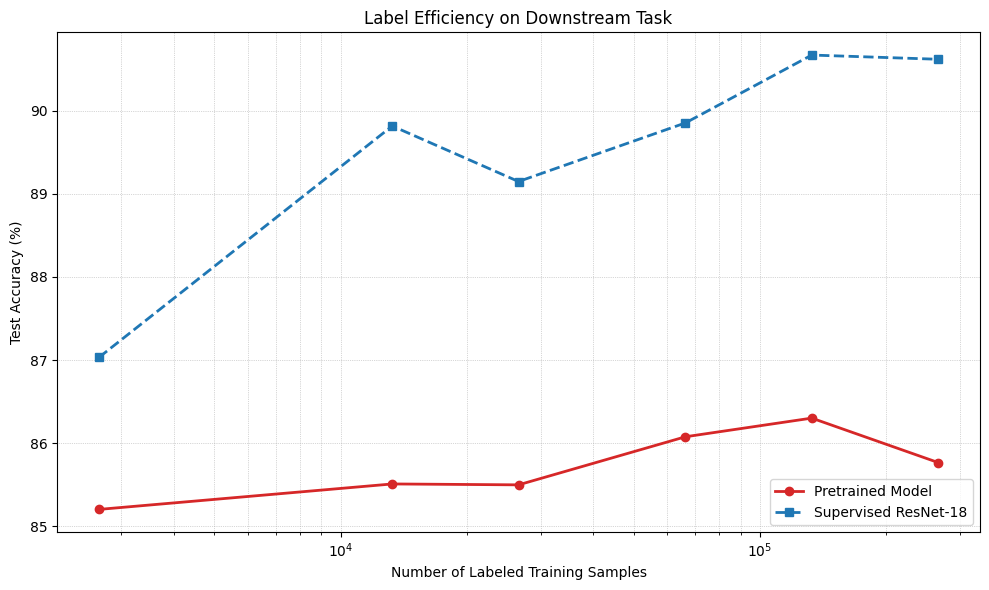

: 

In [ ]:
train_dataset = SleepEDF_Evaluation_Dataset(split="train")
test_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="test"), batch_size=128, shuffle=False)

plot_label_efficiency_experiment(
    train_dataset=train_dataset,
    test_loader=test_loader,
    device=DEVICE,
    fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0]
)